In [ ]:
import numpy as np
import pandas as pd
import matplotlib as plt 
import seborn as sns

In [1]:
"""
COMPLETE MACHINE LEARNING IMPLEMENTATION GUIDE
Includes all algorithms from your exercises + Regression
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, KFold, LeaveOneOut
from sklearn.preprocessing import LabelEncoder, StandardScaler, PolynomialFeatures
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (accuracy_score, confusion_matrix, classification_report,
                           precision_score, recall_score, f1_score, roc_auc_score,
                           mean_absolute_error, mean_squared_error, r2_score)
import warnings
warnings.filterwarnings('ignore')

# ============================================================================
# PART 1: ESSENTIAL EDA (EXPLORATORY DATA ANALYSIS) FUNCTIONS
# ============================================================================

def perform_eda(df, dataset_name="Dataset"):
    """Complete EDA with 10+ functions"""
    print(f"\n{'='*60}")
    print(f"EDA for {dataset_name}")
    print(f"{'='*60}")
    
    # 1. First 5 rows
    print("\n1. HEAD (First 5 rows):")
    print(df.head())
    
    # 2. Dataset info
    print("\n2. INFO (Data types & non-null counts):")
    print(df.info())
    
    # 3. Statistical summary
    print("\n3. DESCRIBE (Statistical summary):")
    print(df.describe())
    
    # 4. Check missing values
    print("\n4. MISSING VALUES:")
    print(df.isnull().sum())
    
    # 5. Check duplicates
    print(f"\n5. DUPLICATES: {df.duplicated().sum()}")
    
    # 6. Shape of dataset
    print(f"\n6. SHAPE: {df.shape[0]} rows × {df.shape[1]} columns")
    
    # 7. Column names
    print(f"\n7. COLUMNS: {df.columns.tolist()}")
    
    # 8. Data types
    print("\n8. DATA TYPES:")
    print(df.dtypes)
    
    # 9. Value counts for categorical columns
    print("\n9. VALUE COUNTS (Categorical columns):")
    for col in df.select_dtypes(include=['object']).columns:
        print(f"\n{col}:")
        print(df[col].value_counts())
    
    # 10. Correlation matrix (for numerical columns)
    print("\n10. CORRELATION MATRIX:")
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    if len(numeric_cols) > 1:
        print(df[numeric_cols].corr())
    
    return df


# ============================================================================
# PART 2: DATA PREPROCESSING FUNCTIONS
# ============================================================================

def preprocess_data(df, target_col, categorical_cols=None, scale_features=True):
    """
    Complete preprocessing pipeline
    """
    print("\n" + "="*60)
    print("PREPROCESSING PIPELINE")
    print("="*60)
    
    # Make a copy to avoid modifying original
    df_processed = df.copy()
    
    # 1. Handle missing values
    print("\n1. HANDLING MISSING VALUES:")
    for col in df_processed.columns:
        if df_processed[col].isnull().sum() > 0:
            if df_processed[col].dtype == 'object':
                df_processed[col].fillna(df_processed[col].mode()[0], inplace=True)
                print(f"   - {col}: Filled with mode")
            else:
                df_processed[col].fillna(df_processed[col].median(), inplace=True)
                print(f"   - {col}: Filled with median")
    
    # 2. Encode categorical variables
    if categorical_cols:
        print("\n2. ENCODING CATEGORICAL VARIABLES:")
        le = LabelEncoder()
        for col in categorical_cols:
            if col in df_processed.columns:
                df_processed[col] = le.fit_transform(df_processed[col])
                print(f"   - {col}: Label Encoded")
    
    # 3. Separate features and target
    X = df_processed.drop(target_col, axis=1)
    y = df_processed[target_col]
    
    print(f"\n3. FEATURES SHAPE: {X.shape}")
    print(f"   TARGET SHAPE: {y.shape}")
    
    # 4. Scale features (optional)
    if scale_features:
        print("\n4. SCALING FEATURES:")
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X)
        X = pd.DataFrame(X_scaled, columns=X.columns)
        print("   StandardScaler applied")
    
    return X, y


# ============================================================================
# PART 3: TRAIN-TEST SPLIT FUNCTION
# ============================================================================

def split_data(X, y, test_size=0.2, random_state=42, stratify=None):
    """Split data into training and testing sets"""
    print(f"\n{'='*60}")
    print(f"TRAIN-TEST SPLIT (test_size={test_size})")
    print("="*60)
    
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=stratify
    )
    
    print(f"\nTraining set size: {X_train.shape[0]} samples")
    print(f"Testing set size: {X_test.shape[0]} samples")
    
    return X_train, X_test, y_train, y_test


# ============================================================================
# PART 4: MODEL EVALUATION FUNCTIONS
# ============================================================================

def evaluate_classification_model(model, X_test, y_test, y_pred=None, model_name="Model"):
    """Complete classification metrics"""
    if y_pred is None:
        y_pred = model.predict(X_test)
    
    print(f"\n{'='*60}")
    print(f"{model_name} - CLASSIFICATION METRICS")
    print("="*60)
    
    # 1. Accuracy
    accuracy = accuracy_score(y_test, y_pred)
    print(f"\n1. ACCURACY: {accuracy:.4f} ({accuracy*100:.2f}%)")
    
    # 2. Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    print(f"\n2. CONFUSION MATRIX:")
    print(cm)
    
    # 3. Precision, Recall, F1-Score
    try:
        precision = precision_score(y_test, y_pred, average='weighted')
        recall = recall_score(y_test, y_pred, average='weighted')
        f1 = f1_score(y_test, y_pred, average='weighted')
        
        print(f"\n3. PRECISION: {precision:.4f}")
        print(f"4. RECALL: {recall:.4f}")
        print(f"5. F1-SCORE: {f1:.4f}")
    except:
        print("\n3. Precision/Recall/F1: Unable to calculate (multi-class?)")
    
    # 4. Classification Report
    print(f"\n6. CLASSIFICATION REPORT:")
    print(classification_report(y_test, y_pred))
    
    # 5. ROC-AUC (for binary classification)
    try:
        if len(np.unique(y_test)) == 2:
            y_pred_proba = model.predict_proba(X_test)[:, 1]
            roc_auc = roc_auc_score(y_test, y_pred_proba)
            print(f"7. ROC-AUC: {roc_auc:.4f}")
    except:
        pass
    
    return {
        'accuracy': accuracy,
        'confusion_matrix': cm,
        'precision': precision if 'precision' in locals() else None,
        'recall': recall if 'recall' in locals() else None,
        'f1': f1 if 'f1' in locals() else None
    }


def evaluate_regression_model(model, X_test, y_test, y_pred=None, model_name="Model"):
    """Complete regression metrics"""
    if y_pred is None:
        y_pred = model.predict(X_test)
    
    print(f"\n{'='*60}")
    print(f"{model_name} - REGRESSION METRICS")
    print("="*60)
    
    # 1. R² Score
    r2 = r2_score(y_test, y_pred)
    print(f"\n1. R² SCORE: {r2:.4f}")
    
    # 2. Adjusted R²
    n = len(y_test)
    p = X_test.shape[1] if hasattr(X_test, 'shape') else 1
    adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)
    print(f"2. ADJUSTED R²: {adj_r2:.4f}")
    
    # 3. MAE
    mae = mean_absolute_error(y_test, y_pred)
    print(f"3. MAE: {mae:.4f}")
    
    # 4. MSE
    mse = mean_squared_error(y_test, y_pred)
    print(f"4. MSE: {mse:.4f}")
    
    # 5. RMSE
    rmse = np.sqrt(mse)
    print(f"5. RMSE: {rmse:.4f}")
    
    return {
        'r2': r2,
        'adj_r2': adj_r2,
        'mae': mae,
        'mse': mse,
        'rmse': rmse
    }


def compare_models(results_dict):
    """Compare multiple models"""
    print(f"\n{'='*60}")
    print("MODEL COMPARISON")
    print("="*60)
    
    comparison_df = pd.DataFrame(results_dict).T
    print(comparison_df)
    return comparison_df


# ============================================================================
# PART 5: ALGORITHM IMPLEMENTATIONS
# ============================================================================

# ----------------------------------------------------------------------------
# 5.1 LINEAR REGRESSION
# ----------------------------------------------------------------------------

def linear_regression_demo(X_train, X_test, y_train, y_test):
    """Complete Linear Regression implementation"""
    print("\n" + "="*60)
    print("LINEAR REGRESSION")
    print("="*60)
    
    # Create and train model
    model = LinearRegression()
    model.fit(X_train, y_train)
    
    # Get coefficients
    print(f"\nMODEL COEFFICIENTS:")
    if hasattr(X_train, 'columns'):
        for i, col in enumerate(X_train.columns):
            print(f"   {col}: {model.coef_[i]:.4f}")
    print(f"   Intercept: {model.intercept_:.4f}")
    
    # Predict
    y_pred = model.predict(X_test)
    
    # Evaluate
    results = evaluate_regression_model(model, X_test, y_test, y_pred, "LINEAR REGRESSION")
    
    return model, results


# ----------------------------------------------------------------------------
# 5.2 POLYNOMIAL REGRESSION
# ----------------------------------------------------------------------------

def polynomial_regression_demo(X_train, X_test, y_train, y_test, degree=2):
    """Complete Polynomial Regression implementation"""
    print("\n" + "="*60)
    print(f"POLYNOMIAL REGRESSION (degree={degree})")
    print("="*60)
    
    # Create polynomial features
    poly = PolynomialFeatures(degree=degree)
    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)
    
    print(f"\nOriginal features: {X_train.shape[1]}")
    print(f"Polynomial features: {X_train_poly.shape[1]}")
    
    # Create and train model
    model = LinearRegression()
    model.fit(X_train_poly, y_train)
    
    # Predict
    y_pred = model.predict(X_test_poly)
    
    # Evaluate
    results = evaluate_regression_model(model, X_test_poly, y_test, y_pred, 
                                       f"POLYNOMIAL REGRESSION (deg={degree})")
    
    return model, results, poly


# ----------------------------------------------------------------------------
# 5.3 LOGISTIC REGRESSION (Classification)
# ----------------------------------------------------------------------------

def logistic_regression_demo(X_train, X_test, y_train, y_test):
    """Complete Logistic Regression implementation"""
    print("\n" + "="*60)
    print("LOGISTIC REGRESSION")
    print("="*60)
    
    # Create and train model
    model = LogisticRegression(max_iter=1000, random_state=42)
    model.fit(X_train, y_train)
    
    # Predict
    y_pred = model.predict(X_test)
    
    # Get probabilities
    try:
        y_proba = model.predict_proba(X_test)
        print(f"\nSample probabilities (first 5):")
        print(y_proba[:5])
    except:
        pass
    
    # Evaluate
    results = evaluate_classification_model(model, X_test, y_test, y_pred, "LOGISTIC REGRESSION")
    
    return model, results


# ----------------------------------------------------------------------------
# 5.4 K-NEAREST NEIGHBORS (KNN)
# ----------------------------------------------------------------------------

def knn_classifier_demo(X_train, X_test, y_train, y_test, n_neighbors=5):
    """Complete KNN Classifier implementation"""
    print("\n" + "="*60)
    print(f"K-NEAREST NEIGHBORS CLASSIFIER (k={n_neighbors})")
    print("="*60)
    
    # Try different k values to find best
    if n_neighbors is None:
        best_k = 1
        best_score = 0
        for k in range(1, 21, 2):
            model = KNeighborsClassifier(n_neighbors=k)
            model.fit(X_train, y_train)
            score = model.score(X_test, y_test)
            if score > best_score:
                best_score = score
                best_k = k
        n_neighbors = best_k
        print(f"\nBest k found: {n_neighbors} (accuracy: {best_score:.4f})")
    
    # Create and train model
    model = KNeighborsClassifier(n_neighbors=n_neighbors, metric='euclidean')
    model.fit(X_train, y_train)
    
    # Predict
    y_pred = model.predict(X_test)
    
    # Evaluate
    results = evaluate_classification_model(model, X_test, y_test, y_pred, 
                                           f"KNN (k={n_neighbors})")
    
    return model, results


def knn_regressor_demo(X_train, X_test, y_train, y_test, n_neighbors=5):
    """KNN Regressor implementation"""
    print("\n" + "="*60)
    print(f"K-NEAREST NEIGHBORS REGRESSOR (k={n_neighbors})")
    print("="*60)
    
    model = KNeighborsRegressor(n_neighbors=n_neighbors)
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    results = evaluate_regression_model(model, X_test, y_test, y_pred, 
                                       f"KNN REGRESSOR (k={n_neighbors})")
    
    return model, results


# ----------------------------------------------------------------------------
# 5.5 NAIVE BAYES CLASSIFIER
# ----------------------------------------------------------------------------

def naive_bayes_demo(X_train, X_test, y_train, y_test):
    """Complete Naive Bayes implementation"""
    print("\n" + "="*60)
    print("NAIVE BAYES CLASSIFIER")
    print("="*60)
    
    # Create and train model
    model = GaussianNB()
    model.fit(X_train, y_train)
    
    # Get class priors
    print(f"\nClass priors: {model.class_prior_}")
    
    # Predict
    y_pred = model.predict(X_test)
    
    # Evaluate
    results = evaluate_classification_model(model, X_test, y_test, y_pred, "NAIVE BAYES")
    
    return model, results


# ----------------------------------------------------------------------------
# 5.6 DECISION TREE
# ----------------------------------------------------------------------------

def decision_tree_demo(X_train, X_test, y_train, y_test, max_depth=None):
    """Complete Decision Tree implementation"""
    print("\n" + "="*60)
    print("DECISION TREE CLASSIFIER")
    print("="*60)
    
    # Create and train model
    model = DecisionTreeClassifier(max_depth=max_depth, random_state=42)
    model.fit(X_train, y_train)
    
    # Feature importance
    if hasattr(X_train, 'columns'):
        print(f"\nFEATURE IMPORTANCE:")
        for i, col in enumerate(X_train.columns):
            print(f"   {col}: {model.feature_importances_[i]:.4f}")
    
    # Predict
    y_pred = model.predict(X_test)
    
    # Evaluate
    results = evaluate_classification_model(model, X_test, y_test, y_pred, "DECISION TREE")
    
    # Visualize tree (optional)
    try:
        plt.figure(figsize=(20,10))
        plot_tree(model, filled=True, feature_names=X_train.columns if hasattr(X_train, 'columns') else None)
        plt.title("Decision Tree Visualization")
        plt.show()
    except:
        pass
    
    return model, results


# ----------------------------------------------------------------------------
# 5.7 CROSS VALIDATION
# ----------------------------------------------------------------------------

def cross_validation_demo(model, X, y, cv=5):
    """Demonstrate cross-validation"""
    print("\n" + "="*60)
    print(f"CROSS VALIDATION (k-fold, k={cv})")
    print("="*60)
    
    # K-Fold Cross Validation
    kf = KFold(n_splits=cv, shuffle=True, random_state=42)
    scores = cross_val_score(model, X, y, cv=kf)
    
    print(f"\nK-FOLD SCORES: {scores}")
    print(f"   Mean: {scores.mean():.4f}")
    print(f"   Std: {scores.std():.4f}")
    
    # Leave-One-Out Cross Validation (for small datasets)
    if X.shape[0] < 50:
        loo = LeaveOneOut()
        loo_scores = cross_val_score(model, X, y, cv=loo)
        print(f"\nLEAVE-ONE-OUT Mean: {loo_scores.mean():.4f}")
    
    return scores


# ============================================================================
# PART 6: DATASET-SPECIFIC IMPLEMENTATIONS
# ============================================================================

# ----------------------------------------------------------------------------
# 6.1 PIMA INDIANS DIABETES DATASET (Naive Bayes)
# ----------------------------------------------------------------------------

def pima_indians_demo():
    """Implementation for Pima Indians Diabetes dataset"""
    print("\n" + "="*60)
    print("PIMA INDIANS DIABETES DATASET - NAIVE BAYES")
    print("="*60)
    
    # Create sample data (since we don't have actual file)
    np.random.seed(42)
    n_samples = 500
    
    data = {
        'pregnancies': np.random.randint(0, 15, n_samples),
        'glucose': np.random.randint(70, 200, n_samples),
        'blood_pressure': np.random.randint(60, 120, n_samples),
        'skin_thickness': np.random.randint(10, 50, n_samples),
        'insulin': np.random.randint(15, 300, n_samples),
        'bmi': np.random.uniform(18, 45, n_samples),
        'dpf': np.random.uniform(0.1, 2.0, n_samples),
        'age': np.random.randint(20, 70, n_samples),
        'outcome': np.random.randint(0, 2, n_samples)
    }
    
    df = pd.DataFrame(data)
    
    # EDA
    perform_eda(df, "Pima Indians Diabetes")
    
    # Preprocess
    X, y = preprocess_data(df, 'outcome')
    
    # Split
    X_train, X_test, y_train, y_test = split_data(X, y, test_size=0.3, stratify=y)
    
    # Naive Bayes
    model, results = naive_bayes_demo(X_train, X_test, y_train, y_test)
    
    # Cross-validation
    cross_validation_demo(model, X, y)
    
    return model, results


# ----------------------------------------------------------------------------
# 6.2 HEART DISEASE DATASET (Naive Bayes / Bayesian Network)
# ----------------------------------------------------------------------------

def heart_disease_demo():
    """Implementation for Heart Disease dataset"""
    print("\n" + "="*60)
    print("HEART DISEASE DATASET - NAIVE BAYES")
    print("="*60)
    
    # Create sample data
    np.random.seed(42)
    n_samples = 300
    
    data = {
        'age': np.random.randint(30, 80, n_samples),
        'sex': np.random.randint(0, 2, n_samples),
        'cp': np.random.randint(0, 4, n_samples),  # chest pain type
        'trestbps': np.random.randint(90, 200, n_samples),  # resting BP
        'chol': np.random.randint(120, 400, n_samples),  # cholesterol
        'fbs': np.random.randint(0, 2, n_samples),  # fasting blood sugar
        'restecg': np.random.randint(0, 3, n_samples),  # resting ECG
        'thalach': np.random.randint(70, 200, n_samples),  # max heart rate
        'exang': np.random.randint(0, 2, n_samples),  # exercise induced angina
        'oldpeak': np.random.uniform(0, 5, n_samples),  # ST depression
        'slope': np.random.randint(0, 3, n_samples),  # slope of peak exercise ST
        'ca': np.random.randint(0, 4, n_samples),  # number of major vessels
        'thal': np.random.randint(0, 3, n_samples),  # thalassemia
        'target': np.random.randint(0, 2, n_samples)  # heart disease
    }
    
    df = pd.DataFrame(data)
    
    # EDA
    perform_eda(df, "Heart Disease")
    
    # Preprocess
    X, y = preprocess_data(df, 'target')
    
    # Split
    X_train, X_test, y_train, y_test = split_data(X, y, test_size=0.3, stratify=y)
    
    # Compare classifiers
    results = {}
    
    # Naive Bayes
    nb_model, nb_results = naive_bayes_demo(X_train, X_test, y_train, y_test)
    results['Naive Bayes'] = nb_results
    
    # KNN
    knn_model, knn_results = knn_classifier_demo(X_train, X_test, y_train, y_test)
    results['KNN'] = knn_results
    
    # Logistic Regression
    lr_model, lr_results = logistic_regression_demo(X_train, X_test, y_train, y_test)
    results['Logistic Regression'] = lr_results
    
    # Compare
    comparison = compare_models(results)
    
    return results, comparison


# ----------------------------------------------------------------------------
# 6.3 TITANIC DATASET (KNN)
# ----------------------------------------------------------------------------

def titanic_demo():
    """Implementation for Titanic dataset"""
    print("\n" + "="*60)
    print("TITANIC DATASET - KNN CLASSIFIER")
    print("="*60)
    
    # Create sample data
    np.random.seed(42)
    n_samples = 500
    
    data = {
        'pclass': np.random.randint(1, 4, n_samples),
        'sex': np.random.choice(['male', 'female'], n_samples),
        'age': np.random.randint(1, 80, n_samples),
        'sibsp': np.random.randint(0, 5, n_samples),
        'parch': np.random.randint(0, 5, n_samples),
        'fare': np.random.uniform(5, 500, n_samples),
        'embarked': np.random.choice(['S', 'C', 'Q'], n_samples),
        'survived': np.random.randint(0, 2, n_samples)
    }
    
    df = pd.DataFrame(data)
    
    # EDA
    perform_eda(df, "Titanic")
    
    # Preprocess (with categorical columns)
    X, y = preprocess_data(df, 'survived', 
                           categorical_cols=['sex', 'embarked'])
    
    # Split
    X_train, X_test, y_train, y_test = split_data(X, y, test_size=0.3, stratify=y)
    
    # KNN with different k values
    print("\nTESTING DIFFERENT K VALUES:")
    for k in [3, 5, 7, 9, 11]:
        model, results = knn_classifier_demo(X_train, X_test, y_train, y_test, n_neighbors=k)
    
    # Best KNN
    best_model, best_results = knn_classifier_demo(X_train, X_test, y_train, y_test)
    
    return best_model, best_results


# ----------------------------------------------------------------------------
# 6.4 WINE QUALITY DATASET (KNN vs Naive Bayes)
# ----------------------------------------------------------------------------

def wine_quality_demo():
    """Implementation for Wine Quality dataset - COMPARISON"""
    print("\n" + "="*60)
    print("WINE QUALITY DATASET - KNN vs NAIVE BAYES")
    print("="*60)
    
    # Create sample data
    np.random.seed(42)
    n_samples = 1000
    
    data = {
        'fixed_acidity': np.random.uniform(4, 16, n_samples),
        'volatile_acidity': np.random.uniform(0.1, 1.5, n_samples),
        'citric_acid': np.random.uniform(0, 1, n_samples),
        'residual_sugar': np.random.uniform(0.5, 15, n_samples),
        'chlorides': np.random.uniform(0.01, 0.2, n_samples),
        'free_sulfur_dioxide': np.random.uniform(2, 70, n_samples),
        'total_sulfur_dioxide': np.random.uniform(5, 200, n_samples),
        'density': np.random.uniform(0.99, 1.005, n_samples),
        'pH': np.random.uniform(2.8, 4, n_samples),
        'sulphates': np.random.uniform(0.3, 2, n_samples),
        'alcohol': np.random.uniform(8, 15, n_samples),
        'quality': np.random.randint(3, 9, n_samples),
        'type': np.random.choice(['white', 'red'], n_samples)
    }
    
    df = pd.DataFrame(data)
    
    # EDA
    perform_eda(df, "Wine Quality")
    
    # Preprocess
    X, y = preprocess_data(df, 'quality', categorical_cols=['type'])
    
    # For classification, we can binarize quality (good/bad)
    y_binary = (y > 5).astype(int)
    print(f"\nBinary target: 0=Bad (<=5), 1=Good (>5)")
    print(f"   Distribution: {np.bincount(y_binary)}")
    
    # Split
    X_train, X_test, y_train, y_test = split_data(X, y_binary, test_size=0.3, stratify=y_binary)
    
    # Compare algorithms
    results = {}
    
    # KNN
    knn_model, knn_results = knn_classifier_demo(X_train, X_test, y_train, y_test, n_neighbors=7)
    results['KNN'] = knn_results
    
    # Naive Bayes
    nb_model, nb_results = naive_bayes_demo(X_train, X_test, y_train, y_test)
    results['Naive Bayes'] = nb_results
    
    # Logistic Regression
    lr_model, lr_results = logistic_regression_demo(X_train, X_test, y_train, y_test)
    results['Logistic Regression'] = lr_results
    
    # Decision Tree
    dt_model, dt_results = decision_tree_demo(X_train, X_test, y_train, y_test, max_depth=5)
    results['Decision Tree'] = dt_results
    
    # Compare
    comparison = compare_models(results)
    
    # User input prediction
    print("\nUSER INPUT PREDICTION EXAMPLE:")
    print("   Enter new wine characteristics for prediction:")
    
    # Take sample input (first test sample)
    sample = X_test.iloc[0:1]
    print(f"\n   Sample features: {sample.values[0]}")
    
    # Predict with all models
    print(f"\n   Predictions:")
    print(f"   - KNN: {knn_model.predict(sample)[0]} ({'Good' if knn_model.predict(sample)[0]==1 else 'Bad'})")
    print(f"   - Naive Bayes: {nb_model.predict(sample)[0]} ({'Good' if nb_model.predict(sample)[0]==1 else 'Bad'})")
    print(f"   - Logistic Regression: {lr_model.predict(sample)[0]} ({'Good' if lr_model.predict(sample)[0]==1 else 'Bad'})")
    print(f"   - Decision Tree: {dt_model.predict(sample)[0]} ({'Good' if dt_model.predict(sample)[0]==1 else 'Bad'})")
    
    return results, comparison


# ----------------------------------------------------------------------------
# 6.5 CUSTOMER CHURN DATASET (Comparison)
# ----------------------------------------------------------------------------

def customer_churn_demo():
    """Implementation for Customer Churn dataset - COMPARISON"""
    print("\n" + "="*60)
    print("CUSTOMER CHURN DATASET - ALGORITHM COMPARISON")
    print("="*60)
    
    # Create sample data
    np.random.seed(42)
    n_samples = 1000
    
    data = {
        'gender': np.random.choice(['Male', 'Female'], n_samples),
        'senior_citizen': np.random.randint(0, 2, n_samples),
        'partner': np.random.choice(['Yes', 'No'], n_samples),
        'dependents': np.random.choice(['Yes', 'No'], n_samples),
        'tenure': np.random.randint(0, 72, n_samples),
        'phone_service': np.random.choice(['Yes', 'No'], n_samples),
        'multiple_lines': np.random.choice(['Yes', 'No', 'No phone service'], n_samples),
        'internet_service': np.random.choice(['DSL', 'Fiber optic', 'No'], n_samples),
        'online_security': np.random.choice(['Yes', 'No', 'No internet service'], n_samples),
        'online_backup': np.random.choice(['Yes', 'No', 'No internet service'], n_samples),
        'device_protection': np.random.choice(['Yes', 'No', 'No internet service'], n_samples),
        'tech_support': np.random.choice(['Yes', 'No', 'No }internet service'], n_samples),
        'streaming_tv': np.random.choice(['Yes', 'No', 'No internet service'], n_samples),
        'streaming_movies': np.random.choice(['Yes', 'No', 'No internet service'], n_samples),
        'contract': np.random.choice(['Month-to-month', 'One year', 'Two year'], n_samples),
        'paperless_billing': np.random.choice(['Yes', 'No'], n_samples),
        'payment_method': np.random.choice(['Electronic check', 'Mailed check', 
                                           'Bank transfer', 'Credit card'], n_samples),
        'monthly_charges': np.random.uniform(20, 120, n_samples),
        'total_charges': np.random.uniform(20, 8000, n_samples),
        'churn': np.random.randint(0, 2, n_samples)
    }
    
    df = pd.DataFrame(data)
    
    # EDA
    perform_eda(df, "Customer Churn")
    
    # Preprocess (many categorical columns)
    categorical_cols = ['gender', 'partner', 'dependents', 'phone_service', 
                       'multiple_lines', 'internet_service', 'online_security',
                       'online_backup', 'device_protection', 'tech_support',
                       'streaming_tv', 'streaming_movies', 'contract',
                       'paperless_billing', 'payment_method']
    
    X, y = preprocess_data(df, 'churn', categorical_cols=categorical_cols)
    
    # Split
    X_train, X_test, y_train, y_test = split_data(X, y, test_size=0.3, stratify=y)
    
    # Compare all algorithms
    results = {}
    
    algorithms = [
        ('KNN', lambda: knn_classifier_demo(X_train, X_test, y_train, y_test, n_neighbors=5)),
        ('Naive Bayes', lambda: naive_bayes_demo(X_train, X_test, y_train, y_test)),
        ('Logistic Regression', lambda: logistic_regression_demo(X_train, X_test, y_train, y_test)),
        ('Decision Tree', lambda: decision_tree_demo(X_train, X_test, y_train, y_test, max_depth=5))
    ]
    
    for name, func in algorithms:
        _, res = func()
        results[name] = res
    
    # Compare
    comparison = compare_models(results)
    
    print("\nBEST ALGORITHM FOR CHURN PREDICTION:")
    best_algo = comparison['accuracy'].idxmax()
    print(f"   {best_algo} with accuracy: {comparison.loc[best_algo, 'accuracy']:.4f}")
    
    return results, comparison


# ============================================================================
# PART 7: REGRESSION EXAMPLES (For your exam)
# ============================================================================

def regression_examples():
    """Regression examples for exam preparation"""
    print("\n" + "="*60)
    print("REGRESSION EXAMPLES")
    print("="*60)
    
    # Create sample regression dataset
    np.random.seed(42)
    n_samples = 200
    
    X = np.random.uniform(0, 10, (n_samples, 1))
    y = 3 * X.squeeze() + 2 + np.random.normal(0, 2, n_samples)
    
    df = pd.DataFrame({
        'feature': X.squeeze(),
        'target': y
    })
    
    # Add polynomial features
    df['feature_sq'] = df['feature'] ** 2
    df['feature_cube'] = df['feature'] ** 3
    
    print("\nSAMPLE REGRESSION DATA:")
    print(df.head())
    
    # Split
    X = df[['feature', 'feature_sq', 'feature_cube']]
    y = df['target']
    X_train, X_test, y_train, y_test = split_data(X, y, test_size=0.3)
    
    # Linear Regression
    lr_model, lr_results = linear_regression_demo(X_train, X_test, y_train, y_test)
    
    # Polynomial Regression (degree 2)
    pr_model, pr_results, poly = polynomial_regression_demo(
        X_train[['feature']], X_test[['feature']], y_train, y_test, degree=2
    )
    
    # KNN Regression
    knn_model, knn_results = knn_regressor_demo(X_train, X_test, y_train, y_test, n_neighbors=5)
    
    # Compare
    regression_results = {
        'Linear': lr_results,
        'Polynomial (deg2)': pr_results,
        'KNN Regressor': knn_results
    }
    
    compare_models(regression_results)
    
    return regression_results


# ============================================================================
# PART 8: MAIN EXECUTION - RUN ALL EXAMPLES
# ============================================================================

if __name__ == "__main__":
    print("\n" + "="*60)
    print("COMPLETE ML EXAM PREPARATION GUIDE")
    print("="*60)
    
    print("\nThis file contains all algorithms needed for your exam:")
    print("   1. EDA Functions (10+ operations)")
    print("   2. Data Preprocessing")
    print("   3. Train-Test Split")
    print("   4. Classification Algorithms:")
    print("      - Naive Bayes")
    print("      - KNN Classifier")
    print("      - Logistic Regression")
    print("      - Decision Tree")
    print("   5. Regression Algorithms:")
    print("      - Linear Regression")
    print("      - Polynomial Regression")
    print("      - KNN Regressor")
    print("   6. Evaluation Metrics")
    print("   7. Cross-Validation")
    print("   8. Dataset-specific implementations")
    
    print("\nTo run any specific demo, uncomment the corresponding line below:")
    print("""
    # Uncomment to run specific demos:
    
    # 1. Pima Indians (Naive Bayes)
    pima_indians_demo()
    
    # 2. Heart Disease (Multiple classifiers)
    # heart_disease_demo()
    
    # 3. Titanic (KNN)
    # titanic_demo()
    
    # 4. Wine Quality (Comparison)
    # wine_quality_demo()
    
    # 5. Customer Churn (All algorithms)
    # customer_churn_demo()
    
    # 6. Regression Examples
    # regression_examples()
    """)
    
    # Run a simple example to verify everything works
    print("\nRunning a quick test:")
    
    # Create simple test data
    X = np.random.rand(100, 2)
    y = (X[:, 0] + X[:, 1] > 1).astype(int)
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
    
    # Test KNN
    knn_classifier_demo(X_train, X_test, y_train, y_test, n_neighbors=5)
    
    print("\n" + "="*60)
    print("ALL FUNCTIONS LOADED SUCCESSFULLY!")
    print("="*60)


COMPLETE ML EXAM PREPARATION GUIDE

This file contains all algorithms needed for your exam:
   1. EDA Functions (10+ operations)
   2. Data Preprocessing
   3. Train-Test Split
   4. Classification Algorithms:
      - Naive Bayes
      - KNN Classifier
      - Logistic Regression
      - Decision Tree
   5. Regression Algorithms:
      - Linear Regression
      - Polynomial Regression
      - KNN Regressor
   6. Evaluation Metrics
   7. Cross-Validation
   8. Dataset-specific implementations

To run any specific demo, uncomment the corresponding line below:

    # Uncomment to run specific demos:

    # 1. Pima Indians (Naive Bayes)
    pima_indians_demo()

    # 2. Heart Disease (Multiple classifiers)
    # heart_disease_demo()

    # 3. Titanic (KNN)
    # titanic_demo()

    # 4. Wine Quality (Comparison)
    # wine_quality_demo()

    # 5. Customer Churn (All algorithms)
    # customer_churn_demo()

    # 6. Regression Examples
    # regression_examples()
    

Running a quick tes


PIMA INDIANS DIABETES DATASET - NAIVE BAYES

EDA for Pima Indians Diabetes

1. HEAD (First 5 rows):
   pregnancies  glucose  blood_pressure  skin_thickness  insulin        bmi  \
0            6      119             116              32      290  20.860129   
1            3       82              92              38      195  22.092373   
2           12      129              96              27      256  20.531437   
3           14      126              86              40      230  33.583665   
4           10      105             114              39      265  41.682738   

        dpf  age  outcome  
0  0.529930   27        1  
1  0.830055   60        0  
2  0.955234   67        0  
3  1.200606   38        1  
4  1.542767   67        0  

2. INFO (Data types & non-null counts):
<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   pregnancies     500 non-nul

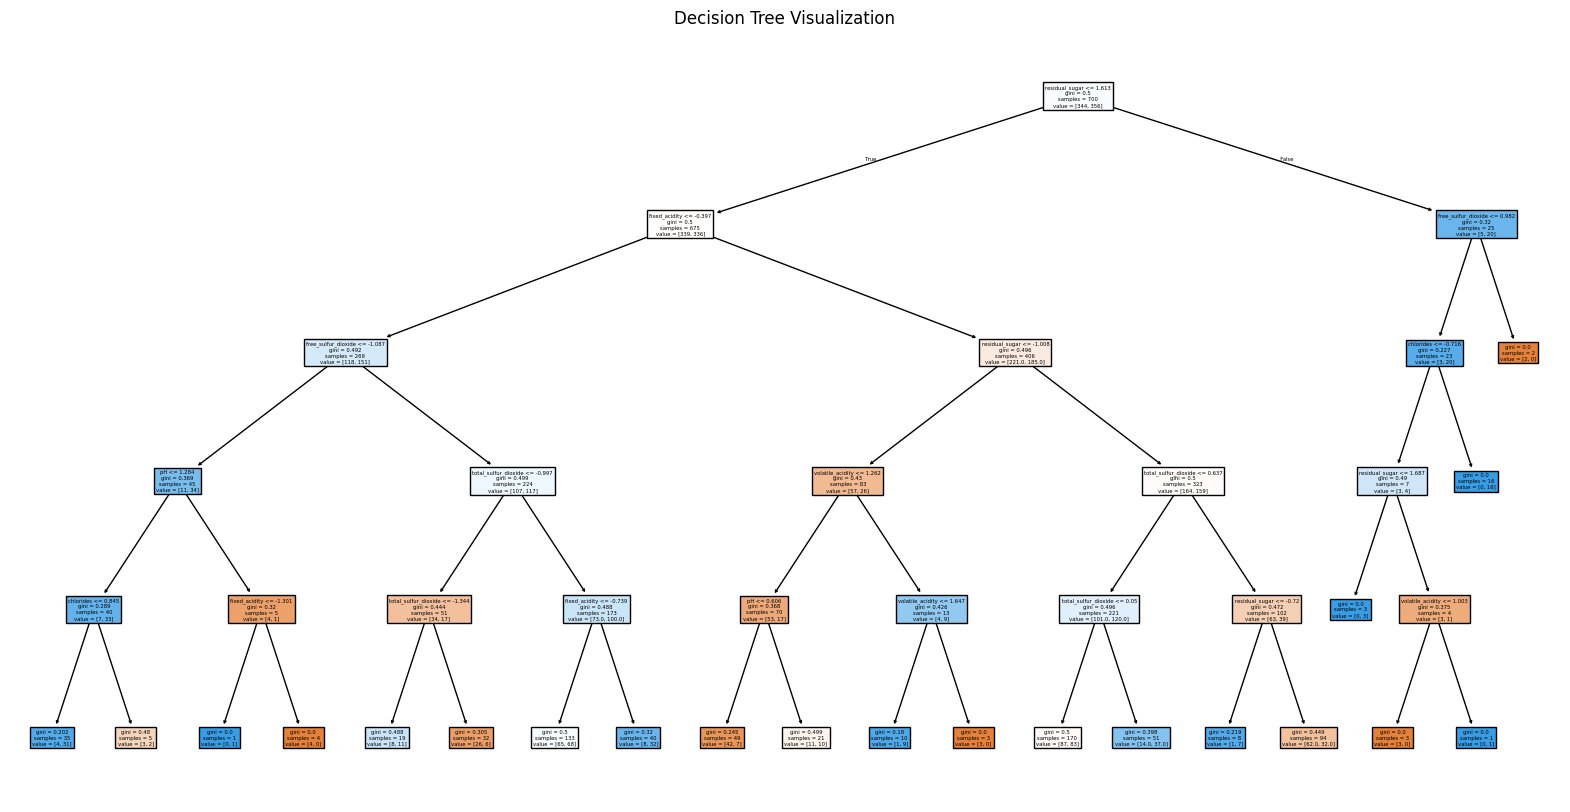


MODEL COMPARISON
                     accuracy      confusion_matrix precision    recall  \
KNN                      0.51  [[63, 85], [62, 90]]  0.509211      0.51   
Naive Bayes          0.486667  [[61, 87], [67, 85]]  0.485492  0.486667   
Logistic Regression  0.493333  [[59, 89], [63, 89]]  0.491913  0.493333   
Decision Tree            0.45  [[76, 72], [93, 59]]  0.450047      0.45   

                           f1  
KNN                  0.506591  
Naive Bayes          0.483911  
Logistic Regression  0.488898  
Decision Tree        0.447811  

USER INPUT PREDICTION EXAMPLE:
   Enter new wine characteristics for prediction:

   Sample features: [ 0.01425985 -1.22815191 -0.15104428 -1.57654352  0.8182015  -0.30220038
 -0.79780215 -0.2338567  -1.68373569 -0.33736797 -0.62280472 -1.00400803]

   Predictions:
   - KNN: 0 (Bad)
   - Naive Bayes: 0 (Bad)
   - Logistic Regression: 0 (Bad)
   - Decision Tree: 0 (Bad)

CUSTOMER CHURN DATASET - ALGORITHM COMPARISON

EDA for Customer Churn

1

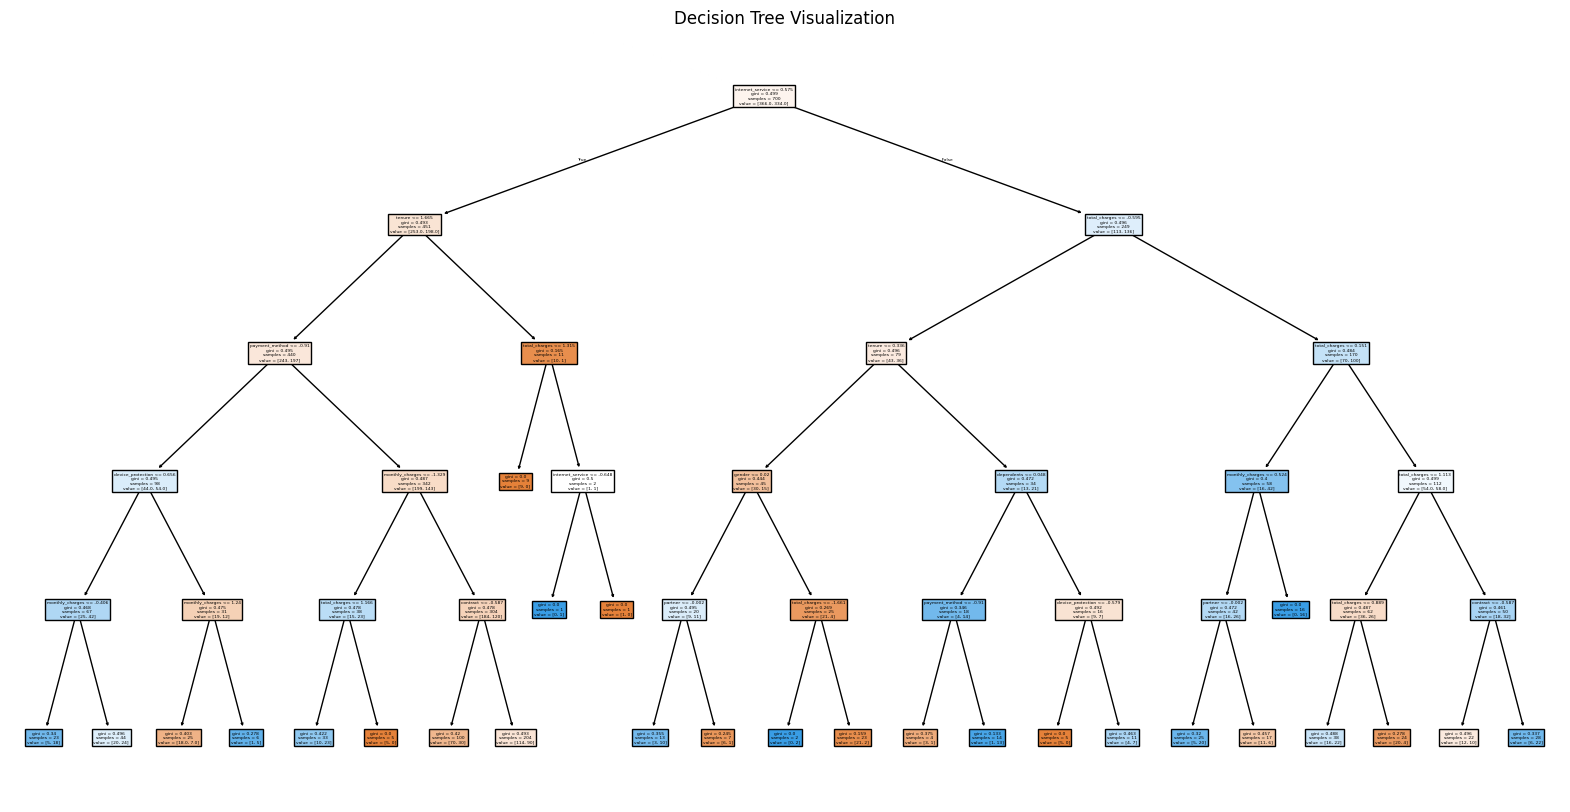


MODEL COMPARISON
                     accuracy       confusion_matrix precision    recall  \
KNN                      0.52   [[82, 75], [69, 74]]  0.520928      0.52   
Naive Bayes          0.533333   [[98, 59], [81, 62]]   0.53076  0.533333   
Logistic Regression  0.533333   [[98, 59], [81, 62]]   0.53076  0.533333   
Decision Tree            0.56  [[106, 51], [81, 62]]  0.558183      0.56   

                           f1  
KNN                  0.520256  
Naive Bayes          0.529167  
Logistic Regression  0.529167  
Decision Tree        0.553405  

BEST ALGORITHM FOR CHURN PREDICTION:
   Decision Tree with accuracy: 0.5600

REGRESSION EXAMPLES

SAMPLE REGRESSION DATA:
    feature     target  feature_sq  feature_cube
0  3.745401  11.876154   14.028030     52.540600
1  9.507143  30.985937   90.385769    859.310439
2  7.319939  24.545963   53.581513    392.213430
3  5.986585  18.531052   35.839198    214.554400
4  1.560186  10.412108    2.434182      3.797777

TRAIN-TEST SPLIT (test_

{'Linear': {'r2': 0.9479963715856001,
  'adj_r2': 0.945210462920543,
  'mae': 1.672284951484338,
  'mse': 4.097675860864583,
  'rmse': np.float64(2.02427168652446)},
 'Polynomial (deg2)': {'r2': 0.9484330639478901,
  'adj_r2': 0.9456705495165271,
  'mae': 1.6429074451122987,
  'mse': 4.063266266647041,
  'rmse': np.float64(2.0157545154723184)},
 'KNN Regressor': {'r2': 0.9376223192153756,
  'adj_r2': 0.9342806577447708,
  'mae': 1.8504436872530439,
  'mse': 4.915109283741732,
  'rmse': np.float64(2.217004574587462)}}

In [12]:
# For Pima Indians (Exercise 3 Q1)
pima_indians_demo()

# For Heart Disease (Exercise 3 Q2)
heart_disease_demo()

# For Titanic (Exercise 3 Q3)
titanic_demo()

# For Wine Quality (Exercise 3 Q4 & Q6)
wine_quality_demo()

# For Customer Churn (Exercise 3 Q5)
customer_churn_demo()

# For Regression examples
regression_examples()

In [14]:
    
# # Import
# from automl import AutoML, quick_ml

# # Method 1: One-line analysis
# ml = quick_ml(df, 'target_column')

# # Method 2: Full control
# ml = AutoML(df, 'target_column', problem_type='classification', test_size=0.2)
# ml.eda()                    # Explore data
# ml.preprocess()             # Clean and prepare
# ml.split_data()             # Train/test split
# ml.train_models()           # Train all algorithms
# ml.evaluate_all()           # Evaluate all models
# ml.show_best_model()        # Show best model
# ml.predict_new([[1, 2, 3]]) # Predict on new data
# ml.compare_models()         # Compare all models

In [2]:
help("automl_quickpipe")


No Python documentation found for 'automl_quickpipe'.
Use help() to get the interactive help utility.
Use help(str) for help on the str class.

